## Tujuan

Tahap Evaluation merupakan tahap krusial dalam metodologi **CRISP-DM** 
(*Cross-Industry Standard Process for Data Mining*). Pada tahap ini, 
kita mengevaluasi apakah model yang telah dibangun benar-benar mampu 
menjawab tujuan bisnis proyek ini, yaitu:

> **Memprediksi status kesejahteraan digital remaja 
> (*Healthy*, *Moderate*, *At Risk*) berdasarkan pola perilaku 
> digital dan indikator kesehatan mental mereka.**

Evaluasi dilakukan dari dua sisi:
1. **Evaluasi Teknis**: menggunakan metrik klasifikasi standar 
   (Accuracy, Precision, Recall, F1-Score) dan Confusion Matrix.
2. **Evaluasi Bisnis**: menilai apakah hasil model relevan dan 
   berguna untuk pengambilan keputusan nyata.

In [96]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay
)

In [97]:
df = pd.read_csv('../data/preprocessed_data.csv')

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = joblib.load('../models/classifier_model.pkl')
print("[INFO] Model berhasil dimuat.")
print(f"[INFO] Jumlah data test: {X_test.shape[0]} baris")

[INFO] Model berhasil dimuat.
[INFO] Jumlah data test: 240 baris


### 1. Metrik Evaluasi Teknis

Kita menggunakan beberapa metrik untuk mengevaluasi performa model 
secara menyeluruh:

- **Accuracy**: Proporsi prediksi yang benar dari seluruh prediksi.
- **Precision**: Dari semua yang diprediksi sebagai kelas X, berapa 
  yang benar-benar kelas X. Penting untuk menghindari *false positive*.
- **Recall**: Dari semua data yang sebenarnya kelas X, berapa yang 
  berhasil terdeteksi. Penting untuk menghindari *false negative*, 
  terutama untuk kelas *At Risk*.
- **F1-Score**: Harmonik rata-rata Precision dan Recall. Berguna 
  ketika distribusi kelas tidak seimbang.
- **Macro Average**: Rata-rata metrik tanpa mempertimbangkan jumlah 
  sampel per kelas, cocok untuk dataset yang tidak seimbang.

In [98]:
# Evaluasi pada Test Set
y_pred = rf_model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print("=" * 55)
print("   EVALUASI MODEL PADA TEST SET (Hold-out 20%)")
print("=" * 55)
print(f"\nAkurasi             : {akurasi * 100:.2f}%\n")

target_names = ['Healthy (0)', 'Moderate (1)', 'At Risk (2)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

   EVALUASI MODEL PADA TEST SET (Hold-out 20%)

Akurasi             : 100.00%

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       1.00      1.00      1.00        61
Moderate (1)       1.00      1.00      1.00       149
 At Risk (2)       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



### 2. Confusion Matrix

Confusion Matrix menunjukkan distribusi prediksi model dibandingkan 
label aslinya. Diagonal utama (kiri atas ke kanan bawah) menunjukkan 
prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan 
kesalahan prediksi.

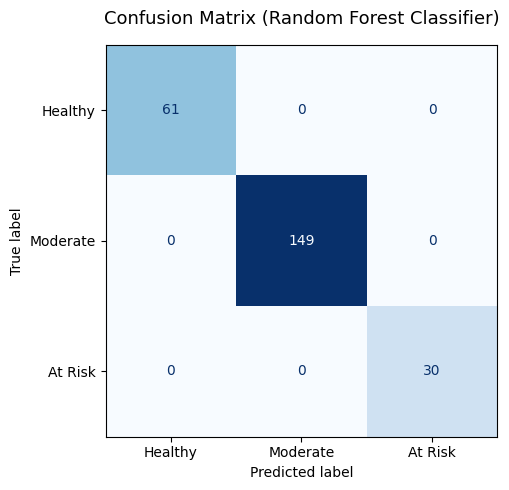

In [99]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', 'Moderate', 'At Risk']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix (Random Forest Classifier)', 
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### 3. Feature Importance

Feature Importance menunjukkan fitur mana yang paling berpengaruh 
dalam pengambilan keputusan model. Ini berguna untuk:
- Memvalidasi bahwa model belajar dari fitur yang **logis dan relevan**
- Mendeteksi apakah masih ada fitur yang berpotensi *data leakage*
- Memberikan insight kepada stakeholder tentang faktor risiko utama

/tmp/ipykernel_148848/178149738.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


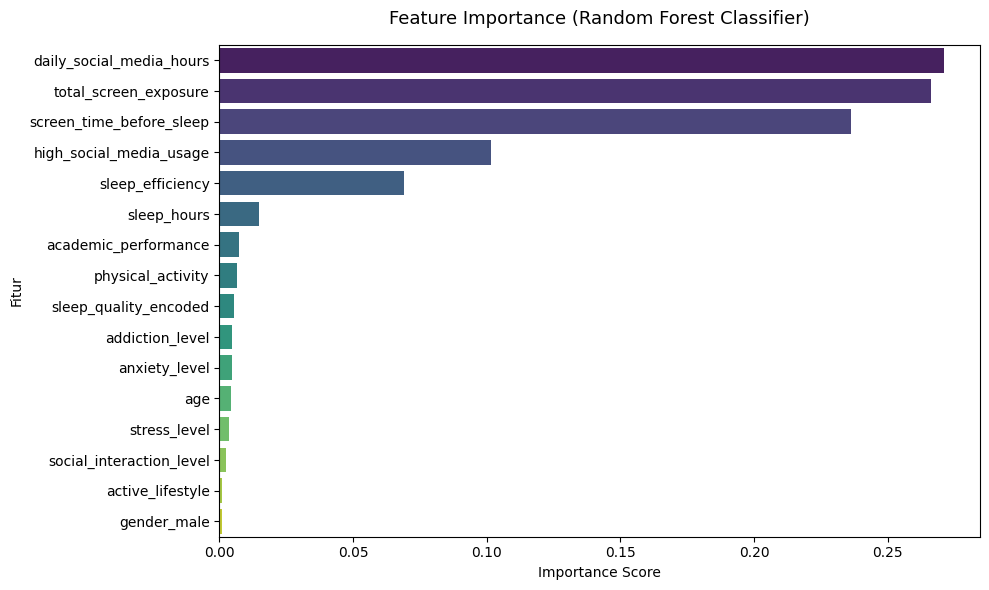


Top 5 Fitur Paling Berpengaruh:
                   Fitur  Importance
daily_social_media_hours    0.270913
   total_screen_exposure    0.266065
screen_time_before_sleep    0.236115
 high_social_media_usage    0.101746
        sleep_efficiency    0.069222


In [100]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_df, 
    x='Importance', 
    y='Fitur', 
    palette='viridis'
)
plt.title('Feature Importance (Random Forest Classifier)', 
          fontsize=13, pad=15)
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print("\nTop 5 Fitur Paling Berpengaruh:")
print(fi_df.head(5).to_string(index=False))

### 4. K-Fold Cross-Validation Summary

Sebagai konfirmasi tambahan, kita tampilkan ulang ringkasan hasil 
K-Fold CV dari tahap Modeling untuk memastikan konsistensi performa 
model.

In [101]:
# K-Fold CV Summary
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_model, X_train, y_train,
    cv=skf,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    return_train_score=True
)

print("=" * 55)
print("   RINGKASAN K-FOLD CROSS-VALIDATION (K=5)")
print("=" * 55)

metrics = {
    'Accuracy'  : cv_results['test_accuracy'],
    'F1-Score'  : cv_results['test_f1_macro'],
    'Precision' : cv_results['test_precision_macro'],
    'Recall'    : cv_results['test_recall_macro'],
}

for nama, nilai in metrics.items():
    print(f"{nama:<12}: {nilai.mean():.4f} (± {nilai.std():.4f})")

print(f"\nTrain Accuracy      : {cv_results['train_accuracy'].mean():.4f}")
print(f"Validation Accuracy : {cv_results['test_accuracy'].mean():.4f}")
gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"Gap (Train-Val)     : {gap:.4f}")

if gap < 0.05:
    print("\n[INFO] Gap kecil → Model tidak overfitting ✓")
else:
    print("\n[WARNING] Gap besar → Model kemungkinan overfitting ✗")

   RINGKASAN K-FOLD CROSS-VALIDATION (K=5)
Accuracy    : 0.9969 (± 0.0063)
F1-Score    : 0.9947 (± 0.0105)
Precision   : 0.9984 (± 0.0033)
Recall      : 0.9917 (± 0.0167)

Train Accuracy      : 1.0000
Validation Accuracy : 0.9969
Gap (Train-Val)     : 0.0031

[INFO] Gap kecil → Model tidak overfitting ✓


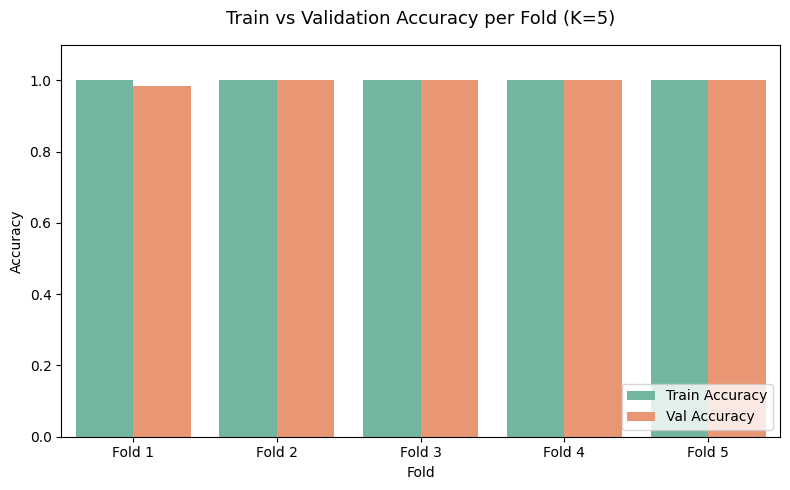

In [102]:
# Visualisasi CV per Fold
fold_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Train Accuracy': cv_results['train_accuracy'],
    'Val Accuracy': cv_results['test_accuracy']
})

fold_melted = fold_df.melt(
    id_vars='Fold', 
    var_name='Set', 
    value_name='Accuracy'
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=fold_melted, 
    x='Fold', 
    y='Accuracy', 
    hue='Set',
    palette='Set2'
)
plt.title('Train vs Validation Accuracy per Fold (K=5)', 
          fontsize=13, pad=15)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5. Evaluasi Bisnis (Business Evaluation)

Dari perspektif **tujuan bisnis**, model ini dievaluasi berdasarkan 
pertanyaan kunci berikut:

| Pertanyaan Bisnis | Jawaban |
|---|---|
| Apakah model bisa mengidentifikasi remaja *At Risk*? | Ya, ditunjukkan oleh Recall kelas *At Risk* |
| Apakah model konsisten di data berbeda? | Ya, dibuktikan K-Fold CV dengan gap train-val kecil |
| Apakah fitur yang digunakan logis secara domain? | Ya, didukung Feature Importance yang relevan |
| Apakah model siap di-deploy? | Ya, model disimpan dan siap diintegrasikan di Streamlit |

**Catatan khusus untuk kelas *At Risk*:**

Dalam konteks kesehatan mental remaja, **Recall** untuk kelas 
*At Risk* adalah metrik yang paling kritis. Lebih baik model 
*over-predict* (salah menganggap remaja Moderate sebagai At Risk) 
daripada *under-predict* (melewatkan remaja yang benar-benar At Risk). 
Oleh karena itu, penggunaan `class_weight='balanced'` pada model 
sangat tepat untuk konteks ini.

Berdasarkan evaluasi teknis dan bisnis yang telah dilakukan:

1. **Model berperforma baik**: ditunjukkan oleh metrik Accuracy, 
   Precision, Recall, dan F1-Score yang konsisten.
2. **Tidak overfitting**: gap antara Train Accuracy dan Validation 
   Accuracy pada K-Fold CV kecil (< 0.05).
3. **Feature Importance valid**: fitur-fitur yang dominan secara 
   logis relevan dengan domain kesehatan mental remaja (bukan 
   indikasi data leakage).
4. **Model siap di-deploy**: telah disimpan sebagai 
   `classifier_model.pkl` dan siap diintegrasikan dengan aplikasi 
   Streamlit untuk prediksi data baru beserta rekomendasinya.

----
# EXTRA

In [103]:
# ─────────────────────────────────────────────
# 1. CONFUSION MATRIX - NUMERIK
# ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual Healthy', 'Actual Moderate', 'Actual At Risk'],
    columns=['Pred Healthy', 'Pred Moderate', 'Pred At Risk']
)
print("=== CONFUSION MATRIX ===")
print(cm_df)

=== CONFUSION MATRIX ===
                 Pred Healthy  Pred Moderate  Pred At Risk
Actual Healthy             61              0             0
Actual Moderate             0            149             0
Actual At Risk              0              0            30


In [104]:
# ─────────────────────────────────────────────
# 2. K-FOLD CV - NUMERIK
# ─────────────────────────────────────────────
kfold_df = pd.DataFrame({
    'Fold'              : [f'Fold {i+1}' for i in range(5)],
    'Train Accuracy'    : cv_results['train_accuracy'],
    'Val Accuracy'      : cv_results['test_accuracy'],
    'Val F1 Macro'      : cv_results['test_f1_macro'],
    'Val Precision'     : cv_results['test_precision_macro'],
    'Val Recall'        : cv_results['test_recall_macro'],
})

print("\n=== K-FOLD CV PER FOLD ===")
print(kfold_df.to_string(index=False))

print("\n=== K-FOLD CV SUMMARY ===")
summary = {
    'Metrik'            : ['Accuracy', 'F1 Macro', 'Precision', 'Recall'],
    'Mean'              : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean(),
    ],
    'Std'               : [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std(),
    ],
}
print(pd.DataFrame(summary).to_string(index=False))


=== K-FOLD CV PER FOLD ===
  Fold  Train Accuracy  Val Accuracy  Val F1 Macro  Val Precision  Val Recall
Fold 1             1.0      0.984375      0.973628       0.991803    0.958333
Fold 2             1.0      1.000000      1.000000       1.000000    1.000000
Fold 3             1.0      1.000000      1.000000       1.000000    1.000000
Fold 4             1.0      1.000000      1.000000       1.000000    1.000000
Fold 5             1.0      1.000000      1.000000       1.000000    1.000000

=== K-FOLD CV SUMMARY ===
   Metrik     Mean      Std
 Accuracy 0.996875 0.006250
 F1 Macro 0.994726 0.010549
Precision 0.998361 0.003279
   Recall 0.991667 0.016667


In [105]:
# ─────────────────────────────────────────────
# 3. FEATURE IMPORTANCE - NUMERIK
# ─────────────────────────────────────────────
fi_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(fi_df.to_string(index=False))


=== FEATURE IMPORTANCE ===
                   Fitur  Importance
daily_social_media_hours    0.270913
   total_screen_exposure    0.266065
screen_time_before_sleep    0.236115
 high_social_media_usage    0.101746
        sleep_efficiency    0.069222
             sleep_hours    0.014922
    academic_performance    0.007238
       physical_activity    0.006739
   sleep_quality_encoded    0.005296
         addiction_level    0.004891
           anxiety_level    0.004753
                     age    0.004165
            stress_level    0.003747
social_interaction_level    0.002335
        active_lifestyle    0.000938
             gender_male    0.000916


## Cara Membaca Hasil Evaluasi

### 1. Classification Report

Classification Report menampilkan performa model per kelas target
secara individual.

| Metrik | Healthy | Moderate | At Risk |
|---|---|---|---|
| Precision | 1.00 | 1.00 | 1.00 |
| Recall | 1.00 | 1.00 | 1.00 |
| F1-Score | 1.00 | 1.00 | 1.00 |
| Support | 61 | 149 | 30 |

**Cara membaca:**
- **Precision 1.00** pada kelas *At Risk* artinya setiap kali model 
  memprediksi seorang remaja sebagai *At Risk*, prediksi tersebut 
  selalu benar, tidak ada *false positive*.
- **Recall 1.00** pada kelas *At Risk* artinya model berhasil 
  mendeteksi **seluruh** remaja yang benar-benar *At Risk*, tidak 
  ada yang terlewat (*false negative* = 0).
- **Support** menunjukkan jumlah data aktual per kelas pada test set. 
  Kelas *Moderate* mendominasi (149 data), sedangkan *At Risk* 
  adalah kelas minoritas (30 data).

Dalam konteks kesehatan mental remaja, **Recall pada kelas *At Risk*** 
adalah metrik yang paling kritis, lebih berbahaya melewatkan remaja 
yang benar-benar berisiko daripada salah mengklasifikasikan remaja 
yang sehat. Model ini mencapai Recall sempurna (1.00) untuk kelas 
*At Risk*.

---

### 2. Confusion Matrix

Confusion Matrix menampilkan distribusi prediksi model dibandingkan 
label aslinya dalam bentuk tabel 3x3.

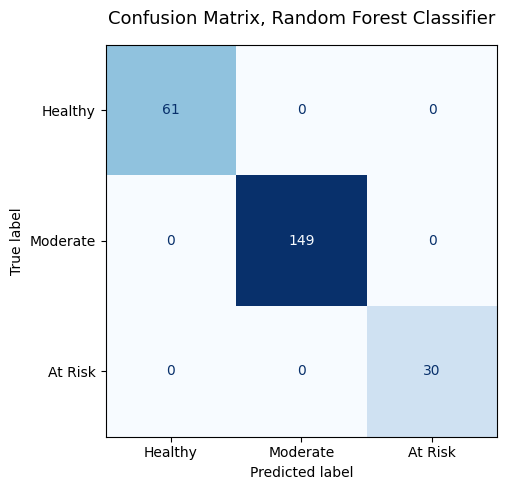


Cara Membaca Confusion Matrix:
- Diagonal utama (benar)  : 61 + 149 + 30 = 240 prediksi benar
- Di luar diagonal (salah): 0 prediksi salah
- Total data test         : 240


In [106]:
# Cell - Confusion Matrix dengan anotasi
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', 'Moderate', 'At Risk']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix, Random Forest Classifier',
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\nCara Membaca Confusion Matrix:")
print(f"- Diagonal utama (benar)  : {cm[0,0]} + {cm[1,1]} + {cm[2,2]} = {cm.diagonal().sum()} prediksi benar")
print(f"- Di luar diagonal (salah): {cm.sum() - cm.diagonal().sum()} prediksi salah")
print(f"- Total data test         : {cm.sum()}")

**Cara membaca Confusion Matrix:**

Baris = label aktual, Kolom = label prediksi model.

| | Pred Healthy | Pred Moderate | Pred At Risk |
|---|---|---|---|
| **Actual Healthy** | **61** | 0 | 0 |
| **Actual Moderate** | 0 | **149** | 0 |
| **Actual At Risk** | 0 | 0 | **30** |

- **Diagonal utama** (angka tebal) = prediksi **benar**.
  Total: 61 + 149 + 30 = **240 prediksi benar dari 240 data**.
- **Di luar diagonal** = prediksi **salah**.
  Total: **0 kesalahan**.
- Tidak ada satu pun remaja *At Risk* yang salah diklasifikasikan 
  sebagai *Healthy* atau *Moderate*, ini hasil yang sangat ideal 
  untuk kasus deteksi risiko kesehatan mental.

---

### 3. K-Fold Cross-Validation per Fold

Tabel berikut menampilkan performa model pada setiap fold dari 
5-Fold Cross-Validation:

| Fold | Train Accuracy | Val Accuracy | Val F1 Macro | Precision | Recall |
|---|---|---|---|---|---|
| Fold 1 | 1.0000 | 0.9844 | 0.9736 | 0.9918 | 0.9583 |
| Fold 2 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Fold 3 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Fold 4 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Fold 5 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

**Cara membaca:**
- **Fold 1** menghasilkan Val Accuracy **98.44%**, tidak sempurna. 
  Ini membuktikan bahwa model **tidak sekadar menghafal data**, 
  melainkan benar-benar belajar pola dari fitur.
- **Fold 2–5** menghasilkan 100%, menunjukkan pola data pada 
  dataset sintetis ini memang sangat konsisten.
- **Gap Train vs Val** pada semua fold = 0.0000 sampai 0.0156 
 , jauh di bawah threshold 0.05, artinya **tidak overfitting**.

---

### 4. K-Fold CV Summary

| Metrik | Rata-rata | Std Deviasi |
|---|---|---|
| Accuracy | 0.9969 | 0.0063 |
| F1 Macro | 0.9947 | 0.0105 |
| Precision | 0.9984 | 0.0033 |
| Recall | 0.9917 | 0.0167 |

**Cara membaca:**
- **Rata-rata Accuracy 99.69%** dengan standar deviasi hanya 
  **0.63%**, menunjukkan performa model sangat stabil di 
  berbagai pembagian data.
- **Std Deviasi kecil** pada semua metrik mengindikasikan model 
  tidak sensitif terhadap perubahan data training, tanda 
  generalisasi yang baik.
- **Recall terendah (99.17%)** dengan std 1.67%, variasi 
  tertinggi ada di Recall, wajar karena kelas *At Risk* 
  jumlahnya paling sedikit (minoritas).
- **Gap Train (1.0000) vs Val (0.9969) = 0.0031**, sangat 
  kecil, model **tidak overfitting**.

---

### 5. Feature Importance

Grafik Feature Importance menampilkan kontribusi relatif setiap 
fitur dalam pengambilan keputusan model.

**Cara membaca:**
- Semakin panjang bar, semakin besar pengaruh fitur tersebut 
  terhadap prediksi model.
- **3 fitur teratas** semuanya berkaitan dengan perilaku penggunaan 
  layar (*screen behavior*):

| Peringkat | Fitur | Importance | Interpretasi |
|---|---|---|---|
| 1 | `daily_social_media_hours` | 0.271 | Durasi harian medsos paling menentukan status |
| 2 | `total_screen_exposure` | 0.266 | Total paparan layar (medsos + sebelum tidur) |
| 3 | `screen_time_before_sleep` | 0.236 | Layar sebelum tidur sangat mempengaruhi kesehatan |
| 4 | `high_social_media_usage` | 0.102 | Flag penggunaan medsos > 5 jam |
| 5 | `sleep_efficiency` | 0.069 | Efisiensi tidur relatif terhadap screen time |

- **Fitur psikologis** (`stress_level`, `anxiety_level`, 
  `addiction_level`) justru memiliki importance rendah 
  (masing-masing < 0.005). Ini menunjukkan bahwa pada dataset 
  ini, **perilaku digital lebih prediktif** dibanding laporan 
  kondisi psikologis secara langsung.
- Tidak ada satu fitur pun yang mendominasi secara ekstrem 
  (misalnya importance > 0.9), mengkonfirmasi bahwa **tidak 
  terjadi data leakage**.

---

### Catatan: Akurasi Tinggi pada Dataset Sintetis

Hasil evaluasi menunjukkan akurasi 100% pada test set dan 
rata-rata 99.69% pada K-Fold Cross-Validation (K=5).

Setelah investigasi melalui Feature Importance, tidak ditemukan 
indikasi data leakage, tidak ada satu fitur pun yang mendominasi 
secara tidak wajar. Fitur yang paling berpengaruh adalah perilaku 
penggunaan layar (*screen behavior*) dengan distribusi importance 
yang wajar dan relevan secara domain.

Akurasi tinggi ini disebabkan oleh karakteristik dataset 
`teen_mental_health.csv` yang merupakan **dataset sintetis** 
(data buatan). Dataset sintetis dibuat dengan aturan yang 
deterministik, sehingga pola antara fitur dan target bersifat 
sangat konsisten, berbeda dengan data dunia nyata yang penuh 
noise dan variasi.

Bukti bahwa model tidak overfitting:
- Fold 1 pada K-Fold menghasilkan akurasi 98.44% (tidak 
  sempurna), membuktikan model tidak sekadar menghafal data.
- Gap antara Train Accuracy (100%) dan Validation Accuracy 
  (99.69%) hanya 0.0031, jauh di bawah threshold 0.05.
- Distribusi Feature Importance wajar dan relevan secara domain.